In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import umap
from itertools import combinations


In [2]:
def column_lookup(col):
    return rename_map.get(col)

In [3]:
vars = pd.DataFrame()

data_dir = '../Data'
for file in os.listdir(data_dir):
    if not file.endswith('.xpt'):
        filepath = os.path.join(data_dir, file)
        var_df = pd.read_csv(filepath, encoding='ANSI')
        vars = pd.concat([vars, var_df], ignore_index=True)

In [4]:
vars['short_desc'] = (
    vars.iloc[:, 1]
    .str.slice(0, 50)
    .str.strip()
    .str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
    .str.replace(r'\s+', '_', regex=True)
    .str.lower()
)

rename_map = dict(zip(vars['Variable Name'], vars['short_desc']))

In [5]:
rename_map['DIQ010'] = 'told_has_diabetes'
rename_map['DIQ050'] = 'taking_insulin'
rename_map['DIQ060U'] = 'insulin_unit_of_measure'
rename_map['DIQ070'] = 'taking_diabetic_oral_agents'
rename_map['DIQ160'] = 'told_has_prediabetes'
rename_map['DIQ180'] = 'blood_test_in_last_3_years'
rename_map['PAD680'] = 'time_sedentary_per_day'
rename_map['PAD790Q'] = 'moderate_intensity_physical_frequency'
rename_map['PAD790U'] = 'moderate_intensity_physical_frequency_unit'
rename_map['PAD800'] = 'moderate_intensity_physical_duration'
rename_map['PAD810Q'] = 'vigorous_intensity_physical_frequency'
rename_map['PAD810U'] = 'vigorous_intensity_physical_frequency_unit'
rename_map['PAD820'] = 'vigorous_intensity_physical_duration'
rename_map['BPQ020'] = 'told_has_hypertension'
rename_map['BPQ030'] = 'told_twice_or_more_hypertension'
rename_map['BPQ080'] = 'told_blood_cholesterol_high'
rename_map['BPQ101D'] = 'taking_cholesterol_medication'
rename_map['BPQ150'] = 'taking_hypertension_medication'
rename_map['MCQ160b'] = 'been_told_congestive_heart_failure'
rename_map['MCA160c'] = 'been_told_coronary_heart_disease'
rename_map['MCQ160d'] = 'been_told_angina_pectoris'
rename_map['MCQ160e'] = 'been_told_had_heart_attack'
rename_map['MCQ160f'] = 'been_told_had_stroke'
rename_map['MCQ160I'] = 'been_told_liver_condition'
rename_map['MCQ170I'] = 'still_have_liver_condition'
rename_map['DBQ930'] = 'prepares_meals'
rename_map['DBQ935'] = 'shares_prepares_meals'
rename_map['DBQ940'] = 'does_food_shopping'
rename_map['DBQ945'] = 'share_food_shopping'
rename_map['KIQ022'] = 'been_told_failing_kidneys'
rename_map['KIQ025'] = 'received_dialysis_last_12_months'
rename_map['OCQ180'] = 'hours_worked_last_week'
rename_map['OCQ210'] = 'works_35_hours'
rename_map['OCQ215'] = 'days_worked_per_week'
rename_map['OCQ383'] = 'main_reason_didnt_work'
rename_map['RIAGENDR'] = 'gender'
rename_map['RIDAGEMN'] = 'age_months_under_24_months'
rename_map['RIDAGEYR'] = 'age_years'
rename_map['RIDRETH3'] = 'race'
rename_map['DID040'] = 'age_diagnosed_diabetes'
rename_map['WHQ070'] = 'tried_to_lose_weight_12_months'
rename_map['WHD020'] = 'weight'
rename_map['WHD050'] = 'weight_one_year_ago'
rename_map['WHD010'] = 'height'

In [6]:
files_to_use = [
    'DIQ_L',
    'PAQ_L',
    'BPQ_L',
    'WHQ_L'
]

columns_to_use = [
    'RIAGENDR',
    'RIDAGEMN',
    'RIDAGEYR',
    'RIDRETH3',
    'LBXGH',
    'LBXGLU',
    'LBXIN',
    'LBDHDD',
    'LBXTC',
    'LBDLDL',
    'LBXTLK',
    'LBXSCR',
    'URDACT',
    'LBXSATSI',
    'LBXSASSI',
    'LBXSGTSI',
    'LBXHSCRP',
    'LBDNENO',
    'LBDLYMNO',
    'LBXVIDMS',
    'LBXFER',
    'LBXSUA',
    'LBXSAL',
    'MCQ160b',
    'MCQ160c',
    'MCQ160d',
    'MCQ160e',
    'MCQ160f',
    'MCQ160I',
    'MCQ170I',
    'DBQ930',
    'DBQ935',
    'DBQ940',
    'DBQ945',
    'KIQ022',
    'KIQ025',
    'OCQ180',
    'OCQ210',
    'OCQ215',
    'OCQ383'
]

In [7]:
dfs = []

for file in os.listdir(data_dir):
    if file.endswith('xpt'):
        filepath = os.path.join(data_dir, file)
        df = pd.read_sas(filepath, encoding='ANSI')
        df['SEQN'] = df['SEQN'].astype(int)
        df = df.loc[:, ~df.columns.duplicated()]
        df = df.set_index('SEQN')
        if file.split('.')[0] in files_to_use:
            dfs.append(df)
        else:
            for col in df.columns:
                if col in columns_to_use:
                    col_df = df[[col]]
                    dfs.append(col_df)


merged = pd.concat(dfs, axis=1)
merged.columns = [column_lookup(col) for col in merged.columns]
merged = merged.loc[:, ~merged.columns.duplicated()]
merged = merged.reset_index()
merged.columns = merged.columns.str.rstrip('_')

In [8]:
merged

,SEQN,albumin_creatinine_ratio_mgg,alanine_aminotransferase_alt_iul,albumin_refrigerated_serum_gdl,aspartate_aminotransferase_ast_iul,creatinine_refrigerated_serum_mgdl,gamma_glutamyl_transferase_ggt_iul,uric_acid_mgdl,told_has_hypertension,told_twice_or_more_hypertension,...,vigorous_intensity_physical_frequency_unit,vigorous_intensity_physical_duration,time_sedentary_per_day,total_cholesterol_mgdl,ldlcholesterol_friedewald_equation_mgdl_lbdl,25hydroxyvitamin_d2_d3,height,weight,weight_one_year_ago,tried_to_lose_weight_12_months
0,130378,17.00,39.0,4.3,25.0,0.80,41.0,5.1,1.0,1.0,...,W,45.0,360.0,264.0,188.0,58.9,71.0,190.0,200.0,1.0
1,130379,6.64,17.0,3.9,20.0,0.79,31.0,8.5,1.0,1.0,...,W,45.0,480.0,214.0,137.0,60.5,70.0,220.0,220.0,2.0
2,130380,7.92,13.0,3.7,15.0,0.64,44.0,4.4,2.0,NaN,...,,NaN,240.0,187.0,63.0,39.4,60.0,150.0,165.0,1.0
3,130381,7.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130386,4.07,34.0,4.3,20.0,0.82,28.0,6.0,2.0,NaN,...,M,30.0,180.0,183.0,109.0,96.9,68.0,200.0,180.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11928,142261,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11929,142276,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11930,142281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11931,142291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


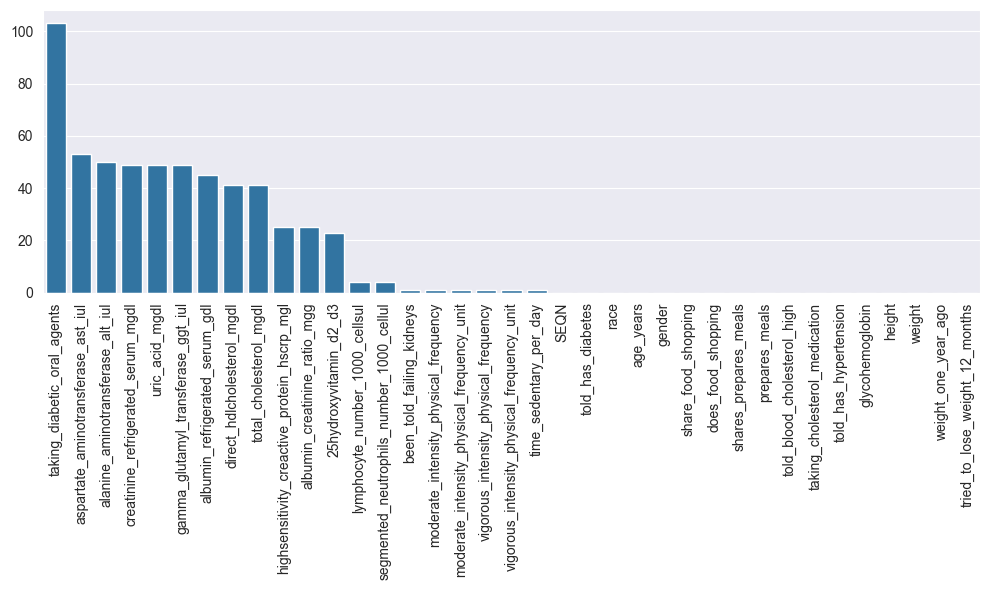

In [9]:
diab = merged[(merged['glycohemoglobin'] >= 6.5) | (merged['fasting_glucose_mgdl'] >= 126)]
diab = diab[diab['age_months_under_24_months'].isnull()]
diab = diab[diab.columns[diab.isnull().sum() <= 200]]

plt.figure(figsize=(10, 6))
sns.barplot(diab.isnull().sum().sort_values(ascending=False))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
len(diab.columns)

37

In [11]:
special_codes = {7, 9}
binary_cols = []

for col in diab.columns:
    if col not in ['gender', 'race']:
        unique_vals = set(diab[col].dropna().unique())
        if unique_vals - special_codes == {1, 2}:
            binary_cols.append(col)

diab[binary_cols] = diab[binary_cols].replace({2: 0})

In [12]:
diab.loc[diab['moderate_intensity_physical_frequency'] < 1, 'moderate_intensity_physical_frequency'] = 0
diab.loc[diab['vigorous_intensity_physical_frequency'] < 1, 'vigorous_intensity_physical_frequency'] = 0

for col in ['moderate_intensity_physical_frequency', 'vigorous_intensity_physical_frequency', 'age_diagnosed_diabetes',
            'height', 'weight', 'weight_one_year_ago']:
    diab[col] = diab[col].replace({7777: np.nan, 9999: np.nan, 999: np.nan})
    diab[col] = diab[col].astype(float)

diab

KeyError: 'age_diagnosed_diabetes'

In [ ]:
def annualize_frequency(row, freq_col, unit_col):
    freq = row[freq_col]
    unit = row[unit_col]

    if pd.isna(freq):
        return np.nan

    if pd.isna(unit) or unit == '':
        return 0.0

    multipliers = {
        'D': 365,
        'W': 52,
        'M': 12,
        'Y': 1
    }

    return freq * multipliers.get(unit, np.nan)

In [ ]:
diab['moderate_ltpa_annual'] = diab.apply(
    annualize_frequency,
    axis=1,
    freq_col='moderate_intensity_physical_frequency',
    unit_col='moderate_intensity_physical_frequency_unit'
)

diab['vigorous_ltpa_annual'] = diab.apply(
    annualize_frequency,
    axis=1,
    freq_col='vigorous_intensity_physical_frequency',
    unit_col='vigorous_intensity_physical_frequency_unit'
)

diab = diab.drop(columns=['moderate_intensity_physical_frequency', 'vigorous_intensity_physical_frequency', 'moderate_intensity_physical_frequency_unit', 'vigorous_intensity_physical_frequency_unit'])

In [ ]:
race_map = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other'
}

gender_map = {
    1: 'Male',
    2: 'Female'
}

In [ ]:
diab['race'] = diab['race'].map(race_map)
diab['gender'] = diab['gender'].map(gender_map)
diab

In [ ]:
diab.to_csv('../Data/test_data.csv', index=False)

## Isolation Forest

In [ ]:
df = pd.read_csv('../Data/test_data.csv')

In [ ]:
id_col = 'SEQN'

continuous_cols = [
    'albumin_creatinine_ratio_mgg',
    'alanine_aminotransferase_alt_iul',
    'albumin_refrigerated_serum_gdl',
    'aspartate_aminotransferase_ast_iul',
    'creatinine_refrigerated_serum_mgdl',
    'gamma_glutamyl_transferase_ggt_iul',
    'uric_acid_mgdl',
    'lymphocyte_number_1000_cellsul',
    'segmented_neutrophils_number_1000_cellul',
    'glycohemoglobin',
    'direct_hdlcholesterol_mgdl',
    'highsensitivity_creactive_protein_hscrp_mgl',
    'total_cholesterol_mgdl',
    '25hydroxyvitamin_d2_d3',
    'height',
    'weight',
    'weight_one_year_ago',
    'age_years',
    'age_diagnosed_diabetes',
    'time_sedentary_per_day',
    'moderate_ltpa_annual',
    'vigorous_ltpa_annual',
]

binary_cols = [
    'told_has_hypertension',
    'told_blood_cholesterol_high',
    'taking_cholesterol_medication',
    'taking_insulin',
    'taking_diabetic_oral_agents',
    'been_told_failing_kidneys',
    'tried_to_lose_weight_12_months',
    'prepares_meals',
    'shares_prepares_meals',
    'does_food_shopping',
    'share_food_shopping',
]

nominal_cols = [
    'gender',
    'race'
]

print(f'Continuous: {len(continuous_cols)}')
print(f'Binary:     {len(binary_cols)}')
print(f'Nominal:    {len(nominal_cols)}')

In [ ]:
df = pd.get_dummies(df, columns=['gender', 'race'], drop_first=True)

oh_cols = [c for c in df.columns if c.startswith('gender_') or c.startswith('race_')]
print(f'One-hot columns added: {oh_cols}')

In [ ]:
X_cont = df[continuous_cols].copy()
X_cont_filled = X_cont.fillna(X_cont.median())

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

df['anomaly_score'] = iso_forest.fit_predict(X_cont_filled)
df['anomaly_raw_score'] = iso_forest.decision_function(X_cont_filled)

n_anomalies = (df['anomaly_score'] == -1).sum()
print(f'Anomalies detected: {n_anomalies} / {len(df)} ({n_anomalies/len(df)*100:.1f}%)')

In [ ]:
anomalies = df[df['anomaly_score'] == -1]
normals = df[df['anomaly_score'] == 1]

comparison = pd.DataFrame({
    'normal_mean': normals[continuous_cols].mean(),
    'anomaly_mean': anomalies[continuous_cols].mean(),
    'normal_std': normals[continuous_cols].std(),
})
comparison['z_diff'] = (
    (comparison['anomaly_mean'] - comparison['normal_mean']) / comparison['normal_std']
)
comparison.sort_values('z_diff', key=abs, ascending=False)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['anomaly_raw_score'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(
    x=df[df['anomaly_score'] == -1]['anomaly_raw_score'].max(),
    color='red', linestyle='--', label='Anomaly threshold'
)
axes[0].set_xlabel('Isolation Forest Decision Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend()


top_feats = comparison['z_diff'].abs().nlargest(4).index.tolist()
melt_df = df[top_feats + ['anomaly_score']].melt(
    id_vars='anomaly_score', var_name='Feature', value_name='Value'
)
melt_df['label'] = melt_df['anomaly_score'].map({1: 'Normal', -1: 'Anomaly'})
sns.boxplot(data=melt_df, x='Feature', y='Value', hue='label', ax=axes[1])
axes[1].set_title('Top Features Separating Anomalies')
plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Remove anomalies
df_clean = df[df['anomaly_score'] == 1].drop(
    columns=['anomaly_score', 'anomaly_raw_score']
).copy()

print(f'Shape after anomaly removal: {df_clean.shape}')

In [ ]:
feature_cols = continuous_cols + binary_cols + oh_cols
X = df_clean[feature_cols].copy()

print(f'Nulls before imputation:\n{X.isnull().sum()[X.isnull().sum() > 0]}')

In [ ]:
mice_imputer = IterativeImputer(
    max_iter=20,
    random_state=42,
    sample_posterior=False
)

X_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X),
    columns=feature_cols,
    index=X.index
)

for col in binary_cols + oh_cols:
    X_imputed[col] = X_imputed[col].round().clip(0, 1).astype(int)

print(f'Remaining nulls: {X_imputed.isnull().sum().sum()}')

In [ ]:
scaler = StandardScaler()
X_imputed[continuous_cols] = scaler.fit_transform(X_imputed[continuous_cols])

In [ ]:
print(f'Final feature matrix: {X_imputed.shape}')
X_imputed

## GMM Clustering

In [ ]:
k_range = range(2, 20)
results = []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )

    gmm.fit(X_imputed)
    labels = gmm.predict(X_imputed)
    sil = silhouette_score(X_imputed, labels)
    results.append({
        'k': k,
        'bic': gmm.bic(X_imputed),
        'aic': gmm.aic(X_imputed),
        'silhouette_score': sil,
        'converged': gmm.converged_
    })
    print(f'k={k:2d}  BIC={gmm.bic(X_imputed):12.1f} '
          f'AIC={gmm.aic(X_imputed):12.1f} '
          f'Silhouette Score={sil:.4f}  Converged={gmm.converged_}')

results_df = pd.DataFrame(results)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['k'], results_df['bic'], 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC')
best_bic_k = int(results_df.loc[results_df['bic'].idxmin(), 'k'])
axes[0].axvline(x=best_bic_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_bic_k}')
axes[0].legend()

axes[1].plot(results_df['k'], results_df['aic'], 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC')
best_aic_k = int(results_df.loc[results_df['aic'].idxmin(), 'k'])
axes[1].axvline(x=best_aic_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_aic_k}')
axes[1].legend()

axes[2].plot(results_df['k'], results_df['silhouette_score'], 'o-', color='seagreen', lw=2)
axes[2].set_xlabel('Number of Components (k)')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette')
best_sil_k = int(results_df.loc[results_df['silhouette_score'].idxmax(), 'k'])
axes[2].axvline(x=best_sil_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_sil_k}')
axes[2].legend()

plt.suptitle('GMM Component Selection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nBest k by BIC:        {best_bic_k}')
print(f'Best k by AIC:        {best_aic_k}')
print(f'Best k by Silhouette: {best_sil_k}')

## UMAP for Dimensionality Reduction prior to GMM

In [ ]:
reducer = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,
    metric='euclidean',
    random_state=42
)

X_embedded = reducer.fit_transform(X_imputed)
print(f'Embedded shape: {X_embedded.shape}')

In [ ]:
k_range = range(2, 20)
results = []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )

    gmm.fit(X_embedded)
    labels = gmm.predict(X_embedded)
    sil = silhouette_score(X_embedded, labels)
    results.append({
        'k': k,
        'bic': gmm.bic(X_embedded),
        'aic': gmm.aic(X_embedded),
        'silhouette_score': sil,
        'converged': gmm.converged_
    })
    print(f'k={k:2d}  BIC={gmm.bic(X_embedded):12.1f} '
          f'AIC={gmm.aic(X_embedded):12.1f} '
          f'Silhouette Score={sil:.4f}  Converged={gmm.converged_}')

results_df = pd.DataFrame(results)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['k'], results_df['bic'], 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('Number of Components (k)')
axes[0].set_ylabel('BIC')
axes[0].set_title('BIC')
best_bic_k = int(results_df.loc[results_df['bic'].idxmin(), 'k'])
axes[0].axvline(x=best_bic_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_bic_k}')
axes[0].legend()

axes[1].plot(results_df['k'], results_df['aic'], 'o-', color='darkorange', lw=2)
axes[1].set_xlabel('Number of Components (k)')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC')
best_aic_k = int(results_df.loc[results_df['aic'].idxmin(), 'k'])
axes[1].axvline(x=best_aic_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_aic_k}')
axes[1].legend()

axes[2].plot(results_df['k'], results_df['silhouette_score'], 'o-', color='seagreen', lw=2)
axes[2].set_xlabel('Number of Components (k)')
axes[2].set_ylabel('Silhouette Score')
axes[2].set_title('Silhouette')
best_sil_k = int(results_df.loc[results_df['silhouette_score'].idxmax(), 'k'])
axes[2].axvline(x=best_sil_k, color='red', ls='--', alpha=0.7, label=f'Best k={best_sil_k}')
axes[2].legend()

plt.suptitle('GMM Component Selection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nBest k by BIC:        {best_bic_k}')
print(f'Best k by AIC:        {best_aic_k}')
print(f'Best k by Silhouette: {best_sil_k}')

## Test Clustering Candidates

In [ ]:
candidates = [5, 6, 7, 11]
models = {}

for k in candidates:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=20,
        random_state=42
    )

    gmm.fit(X_embedded)
    labels = gmm.predict(X_embedded)
    probs = gmm.predict_proba(X_embedded).max(axis=1)
    sil = silhouette_score(X_embedded, labels)

    models[k] = {
        'gmm': gmm,
        'labels': labels,
        'probs': probs,
        'silhouette_score': sil,
        'bic': gmm.bic(X_embedded)
    }

    print(f'\nk={k}  Silhouette={sil:.4f}  BIC={gmm.bic(X_embedded):.1f}  '
          f'Mean confidence={probs.mean():.3f}')
    print(f'  Cluster sizes: {np.bincount(labels).tolist()}')
    print(f'  Smallest cluster: {np.bincount(labels).min()} samples')

In [ ]:
fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 4))

for ax, k in zip(axes, candidates):
    ax.hist(models[k]['probs'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(x=0.5, color='red', ls='--', alpha=0.7, label='50% Threshold')
    ax.set_xlabel('Assignment Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'k={k} (mean={models[k]['probs'].mean():.3f}')
    ax.legend()

plt.suptitle('Cluster Assignment Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
pairs = [(5, 6), (5, 7), (6, 7), (7, 11)]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))

for ax, (k1, k2) in zip(axes, pairs):
    ct = pd.crosstab(
        pd.Series(models[k1]['labels'], name=f'k={k1}'),
        pd.Series(models[k2]['labels'], name=f'k={k2}')
    )
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'k={k1} → k={k2}')

plt.suptitle('Cluster Membership Transitions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Pick for k for GMM

In [ ]:
k = 6
gmm_final = GaussianMixture(
    n_components=k,
    covariance_type='full',
    n_init=20,
    random_state=42
)
gmm_final.fit(X_embedded)

df_clean['cluster'] = gmm_final.predict(X_embedded)
df_clean['cluster_prob'] = gmm_final.predict_proba(X_embedded).max(axis=1)

print(f'Converged: {gmm_final.converged_}')
print(f'\nCluster distribution:')
print(df_clean['cluster'].value_counts().sort_index())
print(f'\nMean assignment confidence: {df_clean["cluster_prob"].mean():.3f}')

### 2D UMAP Visualization

In [ ]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

embedding_2d = reducer_2d.fit_transform(X_imputed)

df_clean['umap_2d_1'] = embedding_2d[:, 0]
df_clean['umap_2d_2'] = embedding_2d[:, 1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('Set2', 6)

for c in range(6):
    mask = df_clean['cluster'] == c
    axes[0].scatter(
        df_clean.loc[mask, 'umap_2d_1'],
        df_clean.loc[mask, 'umap_2d_2'],
        c=[palette[c]], label=f'Cluster {c}',
        alpha=0.6, s=25, edgecolors='none'
    )
axes[0].set_xlabel('UMAP 2D 1')
axes[0].set_ylabel('UMAP 2D 2')
axes[0].set_title('UMAP — GMM Clusters (k=6)')
axes[0].legend(markerscale=2)

# Colored by assignment confidence
sc = axes[1].scatter(
    df_clean['umap_2d_1'], df_clean['umap_2d_2'],
    c=df_clean['cluster_prob'], cmap='RdYlGn',
    alpha=0.6, s=25, edgecolors='none'
)
plt.colorbar(sc, ax=axes[1], label='Assignment Probability')
axes[1].set_xlabel('UMAP 2D 1')
axes[1].set_ylabel('UMAP 2D 2')
axes[1].set_title('UMAP — Assignment Confidence')
plt.suptitle('2D UMAP Visualization - Original Data')

plt.tight_layout()
plt.show()

### 3D UMAP Visualization

In [ ]:
reducer_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)
viz_3d = reducer_3d.fit_transform(X_imputed)

df_clean['umap_3d_1'] = viz_3d[:, 0]
df_clean['umap_3d_2'] = viz_3d[:, 1]
df_clean['umap_3d_3'] = viz_3d[:, 2]

In [ ]:
fig = plt.figure(figsize=(18, 7))
palette = sns.color_palette('Set2', 6)

# --- Cluster scatter ---
ax1 = fig.add_subplot(121, projection='3d')
for c in range(6):
    mask = df_clean['cluster'] == c
    ax1.scatter(
        df_clean.loc[mask, 'umap_3d_1'],
        df_clean.loc[mask, 'umap_3d_2'],
        df_clean.loc[mask, 'umap_3d_3'],
        c=[palette[c]], label=f'Cluster {c}',
        alpha=0.6, s=20, edgecolors='none'
    )
ax1.set_xlabel('UMAP 3D 1')
ax1.set_ylabel('UMAP 3D 2')
ax1.set_zlabel('UMAP 3D 3')
ax1.set_title('UMAP — GMM Clusters (k=6)')
ax1.legend(markerscale=2, fontsize=8)

# --- Confidence scatter ---
ax2 = fig.add_subplot(122, projection='3d')
sc = ax2.scatter(
    df_clean['umap_3d_1'],
    df_clean['umap_3d_2'],
    df_clean['umap_3d_3'],
    c=df_clean['cluster_prob'], cmap='RdYlGn',
    alpha=0.6, s=20, edgecolors='none'
)
fig.colorbar(sc, ax=ax2, label='Assignment Probability', shrink=0.6)
ax2.set_xlabel('UMAP 3D 1')
ax2.set_ylabel('UMAP 3D 2')
ax2.set_zlabel('UMAP 3D 3')
ax2.set_title('UMAP — Assignment Confidence')

plt.suptitle('3D UMAP Visualization - Original Data', fontsize=14)
plt.tight_layout()
plt.show()

### Embedding 2D UMAP Visualization

In [ ]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)
viz_embedding = reducer_2d.fit_transform(X_embedded)

df_clean['umap_emb_2d_1'] = viz_embedding[:, 0]
df_clean['umap_emb_2d_2'] = viz_embedding[:, 1]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('Set2', 6)

for c in range(6):
    mask = df_clean['cluster'] == c
    axes[0].scatter(
        df_clean.loc[mask, 'umap_emb_2d_1'],
        df_clean.loc[mask, 'umap_emb_2d_2'],
        c=[palette[c]], label=f'Cluster {c}',
        alpha=0.6, s=25, edgecolors='none'
    )
axes[0].set_xlabel('Embedded UMAP 2D 1')
axes[0].set_ylabel('Embedded UMAP 2D 2')
axes[0].set_title('UMAP — GMM Clusters (k=6)')
axes[0].legend(markerscale=2)

# Colored by assignment confidence
sc = axes[1].scatter(
    df_clean['umap_emb_1'], df_clean['umap_emb_2'],
    c=df_clean['cluster_prob'], cmap='RdYlGn',
    alpha=0.6, s=25, edgecolors='none'
)
plt.colorbar(sc, ax=axes[1], label='Assignment Probability')
axes[1].set_xlabel('Embedded UMAP 2D 1')
axes[1].set_ylabel('Embedded UMAP 2D 2')
axes[1].set_title('UMAP — Assignment Confidence')
plt.suptitle('UMAP 2D Visualization - Embedded Data')

plt.tight_layout()
plt.show()

### Embedding 3D UMAP Visualization

In [ ]:
reducer_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)
viz_3d = reducer_3d.fit_transform(X_embedded)

df_clean['umap_emb_3d_1'] = viz_3d[:, 0]
df_clean['umap_emb_3d_2'] = viz_3d[:, 1]
df_clean['umap_emb_3d_3'] = viz_3d[:, 2]

In [ ]:
fig = plt.figure(figsize=(18, 7))
palette = sns.color_palette('Set2', 6)

# --- Cluster scatter ---
ax1 = fig.add_subplot(121, projection='3d')
for c in range(6):
    mask = df_clean['cluster'] == c
    ax1.scatter(
        df_clean.loc[mask, 'umap_emb_3d_1'],
        df_clean.loc[mask, 'umap_emb_3d_2'],
        df_clean.loc[mask, 'umap_emb_3d_3'],
        c=[palette[c]], label=f'Cluster {c}',
        alpha=0.6, s=20, edgecolors='none'
    )
ax1.set_xlabel('Embedded UMAP 3D 1')
ax1.set_ylabel('Embedded UMAP 3D 2')
ax1.set_zlabel('Embedded UMAP 3D 3')
ax1.set_title('UMAP — GMM Clusters (k=6)')
ax1.legend(markerscale=2, fontsize=8)

# --- Confidence scatter ---
ax2 = fig.add_subplot(122, projection='3d')
sc = ax2.scatter(
    df_clean['umap_emb_3d_1'],
    df_clean['umap_emb_3d_2'],
    df_clean['umap_emb_3d_3'],
    c=df_clean['cluster_prob'], cmap='RdYlGn',
    alpha=0.6, s=20, edgecolors='none'
)
fig.colorbar(sc, ax=ax2, label='Assignment Probability', shrink=0.6)
ax2.set_xlabel('Embedded UMAP 3D 1')
ax2.set_ylabel('Embedded UMAP 3D 2')
ax2.set_zlabel('Embedded UMAP 3D 3')
ax2.set_title('UMAP — Assignment Confidence')

plt.suptitle('3D UMAP Visualization - Original Data', fontsize=14)
plt.tight_layout()
plt.show()

## Cluster Identification and Phenotyping